In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pysam
import time
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')

In [2]:
from alphagenome.data import genome
from alphagenome.models import dna_client

In [3]:
df = pd.read_csv('./data/GATA1_oligo_synthesis_info.csv')

In [4]:
df = df[['WGATAR_id', 'type', 'oligo_230nt_chr',	'oligo_230nt_start', 'oligo_230nt_end',	'oligo_230nt_strand', 'oligo_seq_230nt']]

In [5]:
df = df.rename(columns={'oligo_230nt_chr':'chr', 'oligo_230nt_start':'start', 'oligo_230nt_end':'end', 'oligo_230nt_strand':'strand','oligo_seq_230nt':'seq'})

In [6]:
df.shape

(5180, 7)

In [7]:
len(df.seq[0])

230

In [8]:
df = df.dropna()

In [9]:
df.shape

(5164, 7)

In [10]:
GATA_id = list(df['WGATAR_id'])
seq_dict = {}
for i in GATA_id:

    chrom = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'original'), 'chr'])[0]
    s = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'original'), 'start'])[0]
    e = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'original'), 'end'])[0]
   
    so = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'original'), 'seq'])[0]
    so = so.upper()
    sm = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'modified'), 'seq'])[0]
    sm = sm.upper()

    seq_dict[i] = {'o':so, 'm':sm, 'start':s, 'end':e, 'chr':chrom}

In [11]:
dna_model = dna_client.create('your_api_key')

In [12]:
output_type = dna_client.OutputType.ATAC
output_term = 'EFO:0002067'

In [13]:
gata_rna_o = pd.DataFrame({'A': range(2048)})
gata_rna_m = pd.DataFrame({'A': range(2048)})
key_list = list( seq_dict.keys())

to_process = set(key_list)
max_attempts = 20

for attempt in range(max_attempts):
    print(f"Attempt {attempt + 1} with {len(to_process)} keys remaining.")
    failed_keys = set()
    for k in tqdm(to_process):
        try:

            seq_record = seq_dict[k]
            o = seq_record['o']
            m = seq_record['m']
        
            output_o = dna_model.predict_sequence(
            sequence=o.center(2048, 'N'),  # Pad to valid sequence length.
            requested_outputs=[output_type],
            ontology_terms=[output_term],  # K562.
            )
        
            output_m = dna_model.predict_sequence(
            sequence=m.center(2048, 'N'),  # Pad to valid sequence length.
            requested_outputs=[output_type],
            ontology_terms=[output_term],  # K562.
            )
        
            output_o = output_o.atac.values
            output_m = output_m.atac.values
            
            gata_rna_o[(k)] = output_o
            gata_rna_m[(k)] = output_m

        except Exception as e:
            if 'RESOURCE_EXHAUSTED' in str(e):
                print(f"Quota exceeded for key {k}, will retry...")
                failed_keys.add(k)
                time.sleep(30)  # Consider sleeping outside the loop for bulk wait
            else:
                raise
    # Only process failed keys in the next attempt
    to_process = failed_keys
    if not to_process:
        print("All keys processed successfully!")
        break
    else:
        print(f"Finished {max_attempts} attempts, {len(to_process)} keys failed: {to_process}")
        

In [14]:
gata_rna_o.to_pickle('./data/GATA_atac_prediction_original_all.pkl')
gata_rna_m.to_pickle('./data/GATA_atac_prediction_modified_all.pkl')

In [15]:
gata_rna_o = pd.read_pickle('./data/GATA_atac_prediction_original_all.pkl')
gata_rna_m = pd.read_pickle('./data/GATA_atac_prediction_modified_all.pkl')

In [16]:
##############################################

In [17]:
mean_o = gata_rna_o.mean().to_frame()
mean_o.columns = ['o']

In [18]:
mean_m = gata_rna_m.mean().to_frame()
mean_m.columns = ['m']

In [19]:
merged = pd.concat([mean_o, mean_m], axis=1, join="inner")

In [20]:
merged = merged.drop("A")

In [21]:
merged['log_o'] = np.log(merged['o'])
merged['log_m'] = np.log(merged['m'])

([<matplotlib.axis.XTick at 0x1550f1bbd950>,
 [Text(0, 0, 'original'), Text(1, 0, 'modified')])

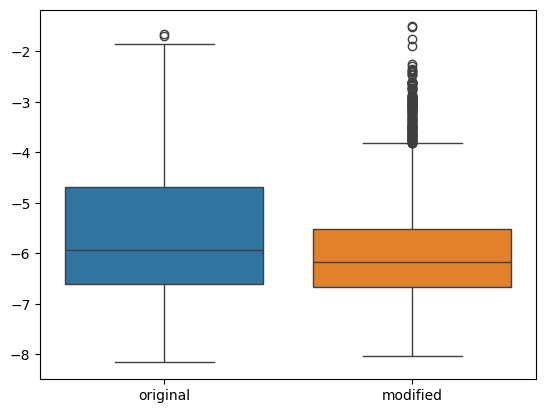

In [48]:
sns.boxplot([merged['log_o'], merged['log_m']],showfliers=True)
plt.xticks([0,1],['original', 'modified'])

In [22]:
merged['delta'] = merged['log_o'] - merged['log_m']

In [23]:
d_cnn = pd.read_pickle('./data/delta_atac.pkl')

In [24]:
d_cnn = d_cnn[['WGATAR_id', 'delta_cnn_atac']]

In [25]:
d_alpha = merged[['delta']]

In [26]:
d_alpha = d_alpha.reset_index().rename(columns={"index": 'WGATAR_id'})

In [27]:
d_alpha

,WGATAR_id,delta
0,WGATAR_1123,2.574668
1,WGATAR_147,0.155568
2,WGATAR_1322,-0.060656
3,WGATAR_845,0.001790
4,WGATAR_721,0.028599
...,...,...
2577,WGATAR_1151,0.051976
2578,WGATAR_172,0.558012
2579,WGATAR_1056,1.908646
2580,WGATAR_610,0.738576


In [28]:
d_merged = d_cnn.merge(d_alpha, on='WGATAR_id', how='inner')

In [40]:
df0 = pd.read_csv('./data/S1_WGATAR_uq_DESeq2_with_TF.csv')

In [41]:
df0 = df0[['WGATAR_id', 'effect2']]
df0.columns = ['WGATAR_id', 'effect']

In [42]:
d_merged = d_merged.merge(df0, on='WGATAR_id', how='inner')

In [43]:
d_merged.to_csv('./data/Atac_seq_model_compare.csv', index=None)

In [44]:
d_merged

,WGATAR_id,delta_cnn_atac,delta,effect2,effect
0,WGATAR_18,0.023948,-0.220937,Negligible,Negligible
1,WGATAR_19,1.252326,1.318706,Negligible,Negligible
2,WGATAR_20,0.596087,1.742543,weak,weak
3,WGATAR_21,-0.006422,0.274268,Negligible,Negligible
4,WGATAR_22,0.382303,0.820558,Negligible,Negligible
...,...,...,...,...,...
1195,WGATAR_2540,0.049911,-0.111075,Negligible,Negligible
1196,WGATAR_2541,1.117475,1.236405,Negligible,Negligible
1197,WGATAR_2542,1.017559,1.639718,Negligible,Negligible
1198,WGATAR_2543,0.761482,1.235139,Negligible,Negligible


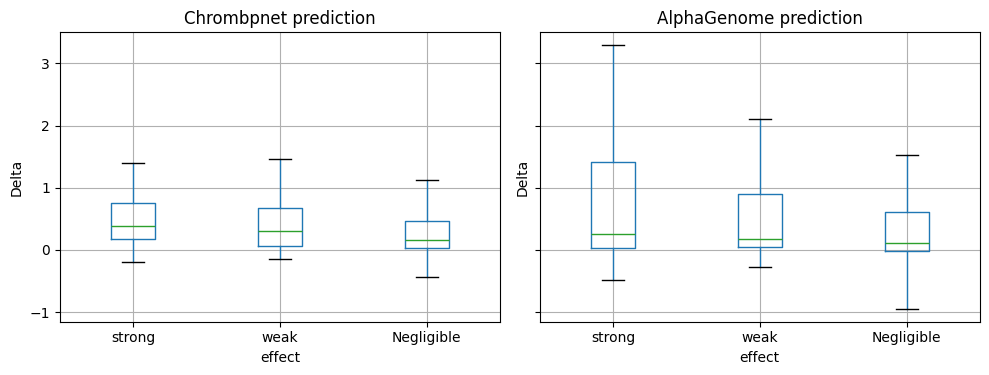

In [45]:
order = ["strong","weak", "Negligible"] 
d_merged["effect"] = pd.Categorical(d_merged["effect"], categories=order, ordered=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

d_merged.boxplot(column='delta_cnn_atac', by='effect', ax=axes[0],showfliers=False )
axes[0].set_title("Chrombpnet prediction")
axes[0].set_xlabel("effect")
axes[0].set_ylabel("Delta")

d_merged.boxplot(column='delta', by='effect', ax=axes[1], showfliers=False)
axes[1].set_title("AlphaGenome prediction")
axes[1].set_xlabel("effect")
axes[1].set_ylabel("Delta")

plt.suptitle("") 
plt.tight_layout()
plt.show()

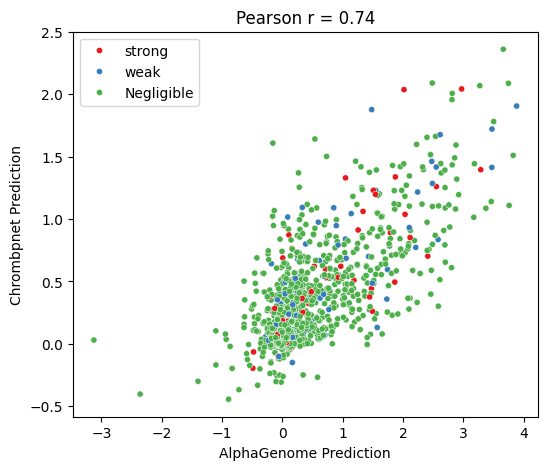

In [46]:
corr = d_merged["delta"].corr(d_merged["delta_cnn_atac"], method="pearson")
plt.figure(figsize=(6, 5))
sns.scatterplot(x="delta", y="delta_cnn_atac", data=d_merged, hue="effect", palette="Set1", s=20)
plt.title(f"Pearson r = {corr:.2f}")
plt.xlabel('AlphaGenome Prediction')
plt.ylabel('Chrombpnet Prediction')
plt.legend()

In [47]:
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

groups = [g["delta_cnn_atac"].values for _, g in d_merged.groupby("effect")]
H, p_kw = kruskal(*groups)
print(f"Kruskal–Wallis: H={H:.3f}, p={p_kw:.3g}")

Kruskal–Wallis: H=19.487, p=5.87e-05


In [48]:
pairs, pvals = [], []
cats = d_merged["effect"].dropna().unique()
for i in range(len(cats)):
    for j in range(i+1, len(cats)):
        a = d_merged.loc[d_merged["effect"]==cats[i], "delta_cnn_atac"]
        b = d_merged.loc[d_merged["effect"]==cats[j], "delta_cnn_atac"]
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        pairs.append((cats[i], cats[j]))
        pvals.append(p)

rej, p_corr, _, _ = multipletests(pvals, method="fdr_bh")
for (a,b), p_raw, p_adj, r in zip(pairs, pvals, p_corr, rej):
    print(f"{a} vs {b}: p_raw={p_raw:.3g}, p_adj={p_adj:.3g}, significant={bool(r)}")

Negligible vs weak: p_raw=0.00274, p_adj=0.00411, significant=True
Negligible vs strong: p_raw=0.000591, p_adj=0.00177, significant=True
weak vs strong: p_raw=0.333, p_adj=0.333, significant=False


In [49]:
pairs, pvals = [], []
cats = d_merged["effect"].dropna().unique()
for i in range(len(cats)):
    for j in range(i+1, len(cats)):
        a = d_merged.loc[d_merged["effect"]==cats[i], "delta"]
        b = d_merged.loc[d_merged["effect"]==cats[j], "delta"]
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        pairs.append((cats[i], cats[j]))
        pvals.append(p)

rej, p_corr, _, _ = multipletests(pvals, method="fdr_bh")
for (a,b), p_raw, p_adj, r in zip(pairs, pvals, p_corr, rej):
    print(f"{a} vs {b}: p_raw={p_raw:.3g}, p_adj={p_adj:.3g}, significant={bool(r)}")

Negligible vs weak: p_raw=0.0205, p_adj=0.0308, significant=True
Negligible vs strong: p_raw=0.0149, p_adj=0.0308, significant=True
weak vs strong: p_raw=0.57, p_adj=0.57, significant=False
